### AdVise — Milestone 2
#### Basic EDA + Baseline Models

In [12]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

In [26]:
# =========================
# DB CRUD READ (Task 5)
# =========================
import sys
import os
sys.path.append(os.path.abspath("../etl/db/scripts/utils"))

from db_helpers import get_connection, select_all

try:
    conn = get_connection()
    cur = conn.cursor()

    campaigns = select_all(cur, "campaigns")
    ads = select_all(cur, "ads")
    audience = select_all(cur, "audience")
    predictions = select_all(cur, "predictions")

    print("campaigns rows:", len(campaigns))
    print("ads rows:", len(ads))
    print("audience rows:", len(audience))
    print("predictions rows:", len(predictions))

    cur.close()
    conn.close()
    print("\nDB read successful via CRUD helpers.")

except Exception as e:
    print("DB not available, falling back to CSV:", e)

DB not available, falling back to CSV: connection to server at "localhost" (::1), port 5432 failed: FATAL:  password authentication failed for user "postgres"



In [13]:
# =========================
# STEP 1: LOAD DATA + BASIC EDA
# =========================

df = pd.read_csv("../etl/db/data_clean/training_dataset.csv")
df.head()

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\n================= INFO =================")
print(df.info())

print("\n================= MISSING VALUES =================")
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print(missing_df)

print("\n================= DUPLICATES =================")
print("Duplicate rows:", df.duplicated().sum())

print("\n================= NUMERICAL STATS =================")
display(df.describe(include=[np.number]).T)

print("\n================= CATEGORICAL STATS =================")
cat_cols = df.select_dtypes(include=["string", "bool"]).columns

display(df[cat_cols].describe().T)

Shape: (210000, 25)

Columns:
 Index(['platform', 'budget', 'duration_days', 'campaign_intent',
       'product_type', 'cta_type', 'age', 'gender', 'location', 'interests',
       'audience_temperature', 'customer_type', 'career', 'creative_type',
       'copy_text_length', 'aspect_ratio', 'visual_complexity', 'has_person',
       'ctr', 'conversion_rate', 'engagement_score', 'reach_score',
       'lead_rate', 'data_source', 'is_synthetic'],
      dtype='str')

================= INFO =================
<class 'pandas.DataFrame'>
RangeIndex: 210000 entries, 0 to 209999
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   platform              210000 non-null  str    
 1   budget                210000 non-null  float64
 2   duration_days         210000 non-null  int64  
 3   campaign_intent       210000 non-null  str    
 4   product_type          210000 non-null  str    
 5   cta_type              21

,count,mean,std,min,25%,50%,75%,max
budget,210000.0,500.000000,0.000000,500.000000,500.000000,500.000000,500.000000,500.000000
duration_days,210000.0,33.032076,15.287693,7.000000,20.000000,33.000000,46.000000,59.000000
copy_text_length,210000.0,20.993590,10.675698,3.000000,12.000000,21.000000,30.000000,39.000000
visual_complexity,210000.0,0.499889,0.230558,0.100004,0.300651,0.499011,0.700125,0.899998
ctr,210000.0,0.134822,0.130191,0.001003,0.052780,0.095772,0.163880,0.992024
conversion_rate,210000.0,0.076257,0.043136,0.000000,0.040000,0.080000,0.110000,0.150000
engagement_score,200000.0,5.494710,2.872581,1.000000,3.000000,5.000000,8.000000,10.000000
reach_score,210000.0,54.982248,25.990077,10.001610,32.455323,54.984207,77.516097,99.999852
lead_rate,210000.0,0.061005,0.034509,0.000000,0.032000,0.064000,0.088000,0.120000



================= CATEGORICAL STATS =================


,count,unique,top,freq
platform,210000,6,facebook,42819
campaign_intent,210000,5,sales,42352
product_type,210000,10,fitness,21242
cta_type,210000,4,learn_more,52565
age,210000,5,55+,42105
gender,210000,2,male,105173
location,210000,7,UK,30258
interests,210000,10,gaming,21208
audience_temperature,210000,3,warm,70061
customer_type,210000,2,returning,105103


In [14]:
# =========================
# STEP 2: TARGET + CLEANING
# =========================

df_model = df.copy()

# Target variable
target = "ctr"

# Drop constant/useless column
df_model = df_model.drop(columns=["budget"])

# Impute missing engagement_score with median
df_model["engagement_score"] = df_model["engagement_score"].fillna(
    df_model["engagement_score"].median()
)

print("Missing values after cleaning:", df_model.isnull().sum().sum())

X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSynthetic distribution:")
print(df_model["is_synthetic"].value_counts(normalize=True))

Missing values after cleaning: 0
X shape: (210000, 23)
y shape: (210000,)

Synthetic distribution:
is_synthetic
False    1.0
Name: proportion, dtype: float64


In [16]:
# =========================
# STEP 3: ENCODING
# =========================

df_enc = df_model.copy()

# Detect ALL non-numeric columns (object + bool)
cat_cols = df_enc.select_dtypes(include=["object", "str", "bool"]).columns.tolist()
print("Columns to encode:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    encoders[col] = le

print("\nEncoding completed.")
print("New dataset shape:", df_enc.shape)

# Verify all columns are now numeric
non_numeric = df_enc.select_dtypes(exclude="number").columns.tolist()
print("Remaining non-numeric columns:", non_numeric)  # Should be empty []

display(df_enc.head())

Columns to encode: ['platform', 'campaign_intent', 'product_type', 'cta_type', 'age', 'gender', 'location', 'interests', 'audience_temperature', 'customer_type', 'career', 'creative_type', 'aspect_ratio', 'has_person', 'data_source', 'is_synthetic']

Encoding completed.
New dataset shape: (210000, 24)
Remaining non-numeric columns: []


,platform,duration_days,campaign_intent,product_type,cta_type,age,gender,location,interests,audience_temperature,...,aspect_ratio,visual_complexity,has_person,ctr,conversion_rate,engagement_score,reach_score,lead_rate,data_source,is_synthetic
0,1,11,2,2,0,3,0,5,1,0,...,1,0.628978,1,0.006061,0.0,5.0,31.226951,0.0,0,0
1,1,48,2,2,0,0,1,4,5,0,...,1,0.644540,1,0.009322,0.0,5.0,94.823227,0.0,0,0
2,1,41,0,9,1,1,1,5,2,0,...,1,0.512732,1,0.010330,0.0,5.0,88.286184,0.0,0,0
3,1,30,1,8,3,0,0,1,5,0,...,1,0.760484,0,0.015729,0.0,5.0,96.850654,0.0,0,0
4,1,29,4,5,2,3,0,6,2,2,...,1,0.625339,0,0.014088,0.0,5.0,60.804135,0.0,0,0


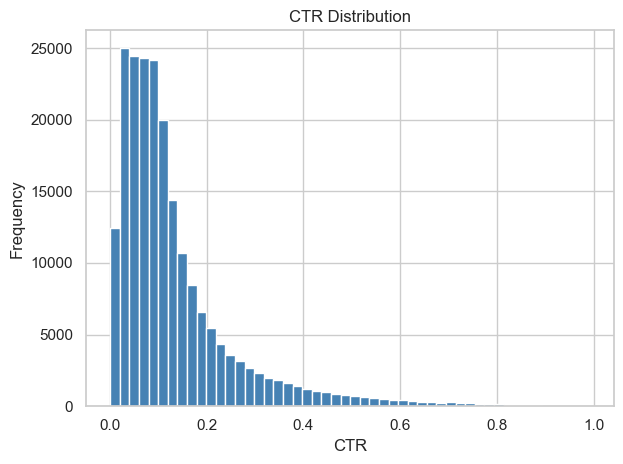

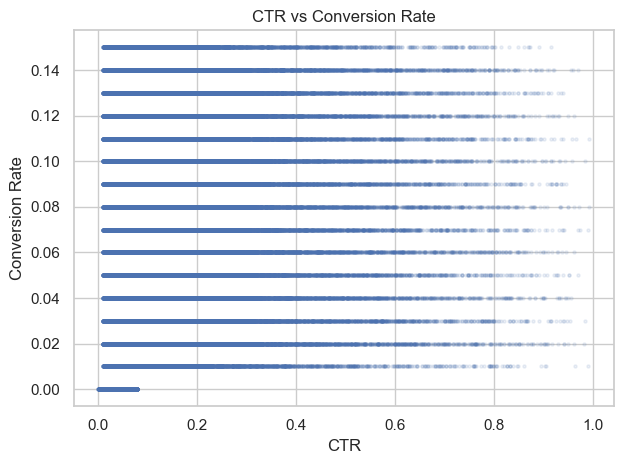

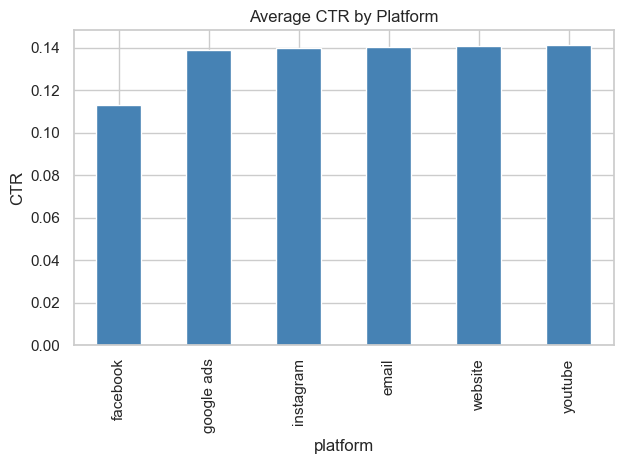

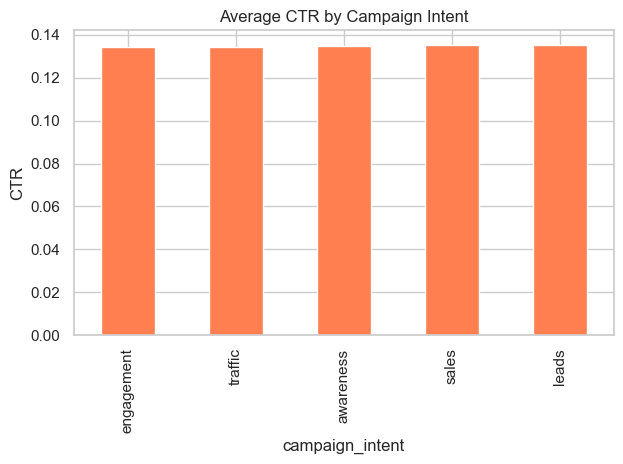

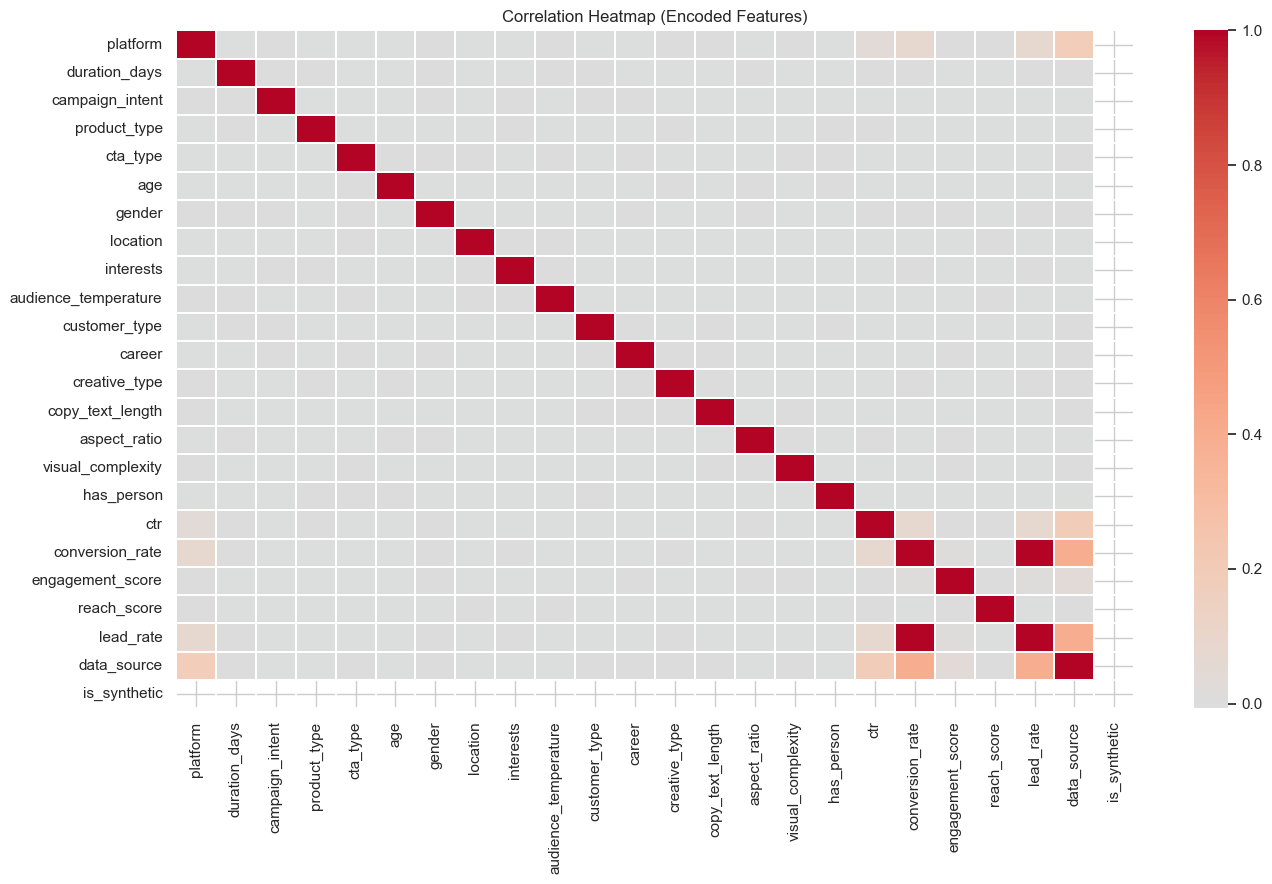


Top correlations with CTR:


data_source          0.191812
lead_rate            0.075778
conversion_rate      0.075778
platform             0.038097
location            -0.004577
interests           -0.002933
visual_complexity   -0.002863
product_type         0.001909
age                 -0.001908
aspect_ratio         0.001823
Name: ctr, dtype: float64

In [17]:
# =========================
# STEP 4: EDA VISUALIZATIONS
# =========================

# 1. CTR distribution
plt.figure()
plt.hist(df_model["ctr"], bins=50, color="steelblue", edgecolor="white")
plt.title("CTR Distribution")
plt.xlabel("CTR")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2. CTR vs Conversion Rate
plt.figure()
plt.scatter(df_model["ctr"], df_model["conversion_rate"], alpha=0.1, s=5)
plt.title("CTR vs Conversion Rate")
plt.xlabel("CTR")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

# 3. Average CTR by Platform
plt.figure()
df_model.groupby("platform")["ctr"].mean().sort_values().plot(kind="bar", color="steelblue")
plt.title("Average CTR by Platform")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

# 4. Average CTR by Campaign Intent
plt.figure()
df_model.groupby("campaign_intent")["ctr"].mean().sort_values().plot(kind="bar", color="coral")
plt.title("Average CTR by Campaign Intent")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

# 5. Correlation heatmap — numeric only (THE FIX)
plt.figure(figsize=(14, 9))
numeric_df = df_enc.select_dtypes(include="number")
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap (Encoded Features)")
plt.tight_layout()
plt.show()

# 6. Top correlations with CTR
print("\nTop correlations with CTR:")
display(corr["ctr"].drop("ctr").sort_values(key=abs, ascending=False).head(10))

In [18]:
# =========================
# STEP 5: BASELINE MODELS
# =========================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Prepare encoded features (drop non-predictive columns)
drop_cols = ["is_synthetic", "data_source"]  # metadata, not features
feature_cols = [c for c in df_enc.columns if c not in [target] + drop_cols]

X_enc = df_enc[feature_cols]
y_enc = df_enc[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42
)

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# --- Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest (100 trees)": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    # Linear models use scaled data
    if "Regression" in name:
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": round(mae, 6), "R²": round(r2, 4)})
    print(f"{name:35s} | MAE: {mae:.6f} | R²: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
display(results_df)

Linear Regression                   | MAE: 0.089423 | R²: 0.0048
Ridge Regression                    | MAE: 0.089423 | R²: 0.0048
Random Forest (100 trees)           | MAE: 0.093226 | R²: 0.0006
Gradient Boosting                   | MAE: 0.086903 | R²: 0.0350


,Model,MAE,R²
3,Gradient Boosting,0.086903,0.0350
0,Linear Regression,0.089423,0.0048
1,Ridge Regression,0.089423,0.0048
2,Random Forest (100 trees),0.093226,0.0006


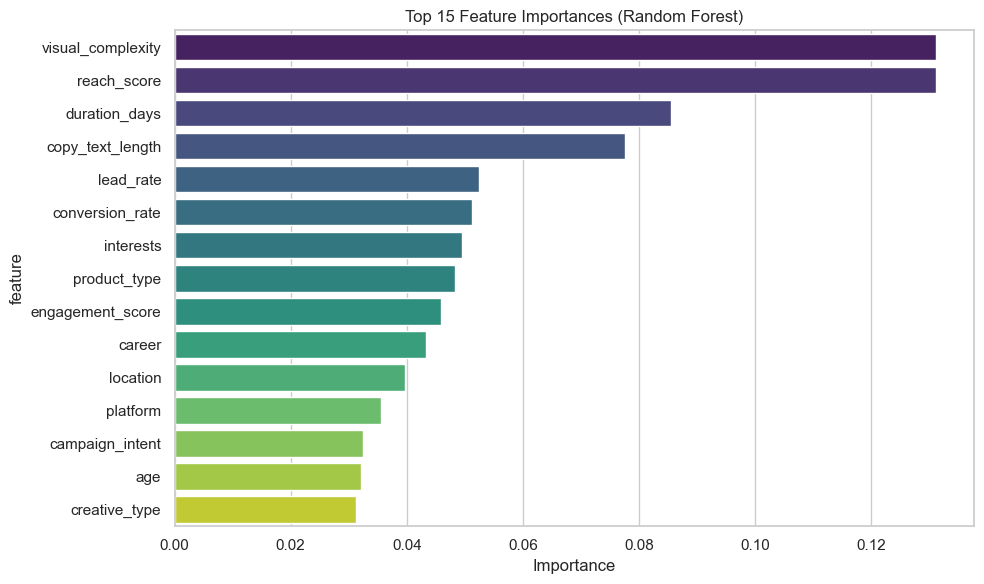


--- Feature Documentation ---

TARGET VARIABLE:
  ctr (Click-Through Rate) — continuous float, ratio of clicks to impressions.

TOP 15 FEATURES BY RANDOM FOREST IMPORTANCE:
  visual_complexity    — numerical score for ad creative complexity
  reach_score          — estimated audience reach for the campaign
  duration_days        — campaign length in days
  copy_text_length     — character length of the ad copy text
  lead_rate            — ratio of leads generated (post-campaign metric)
  conversion_rate      — ratio of conversions (post-campaign metric)
  interests            — encoded audience interest category
  product_type         — encoded category of the advertised product
  engagement_score     — user engagement signal, median-imputed where missing
  career               — encoded audience career/occupation segment
  location             — encoded target geographic region
  platform             — encoded ad platform (facebook, instagram, etc.)
  campaign_intent      — encoded 

In [22]:
# =========================
# STEP 6: FEATURE IMPORTANCE + DOCUMENTATION
# =========================

# Use Random Forest feature importance
rf_model = models["Random Forest (100 trees)"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\n--- Feature Documentation ---")
print("""
TARGET VARIABLE:
  ctr (Click-Through Rate) — continuous float, ratio of clicks to impressions.

TOP 15 FEATURES BY RANDOM FOREST IMPORTANCE:
  visual_complexity    — numerical score for ad creative complexity
  reach_score          — estimated audience reach for the campaign
  duration_days        — campaign length in days
  copy_text_length     — character length of the ad copy text
  lead_rate            — ratio of leads generated (post-campaign metric)
  conversion_rate      — ratio of conversions (post-campaign metric)
  interests            — encoded audience interest category
  product_type         — encoded category of the advertised product
  engagement_score     — user engagement signal, median-imputed where missing
  career               — encoded audience career/occupation segment
  location             — encoded target geographic region
  platform             — encoded ad platform (facebook, instagram, etc.)
  campaign_intent      — encoded campaign goal (awareness, leads, traffic, etc.)
  age                  — encoded audience age group
  creative_type        — encoded format of the ad creative (video, image, etc.)

DROPPED FEATURES:
  budget               — constant/zero-variance column, dropped
  is_synthetic         — metadata flag, not a predictor
  data_source          — metadata, not a predictor (also showed artificial
                         correlation with CTR of 0.19 — likely a labeling artifact)

ASSUMPTIONS:
  - All rows in this dataset are real (is_synthetic = False, confirmed in EDA)
  - engagement_score NaNs are missing-at-random, imputed with median
  - CTR is treated as a regression target (not binned/classified)
  - lead_rate and conversion_rate are kept as features since they are
    available as training signals (post-campaign data in the training set)
""")